# Telco Customer Churn Prediction

## Problem Statement
The objective of this project is to predict whether a customer will churn (leave the service) based on their usage patterns, demographics, and account information.

This helps telecom companies:
- Reduce customer churn
- Improve retention strategies
- Identify high-risk customers proactively

## Import Required Libraries

We import libraries for:
- Data manipulation → Pandas, NumPy  
- Visualization → Matplotlib, Seaborn  
- Machine Learning → Scikit-learn  
- Pipeline & preprocessing → sklearn, imblearn  

### Load Dataset

- Load the Telco dataset
- Inspect first few rows
- Understand structure and columns

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Understanding

We explore:
- Data types (categorical vs numerical)
- Unique values in each column
- Business meaning of features (e.g., tenure, contract type)

## Exploratory Data Analysis (EDA)

We analyze:
- Distribution of churn vs non-churn customers
- Key features affecting churn (tenure, charges, contract)
- Correlation and patterns in data

<AxesSubplot:xlabel='Churn', ylabel='count'>

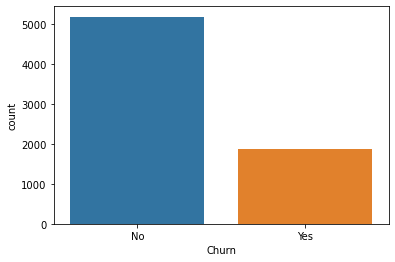

In [5]:
sns.countplot(x='Churn',data=df)
# sns.countplot(x='Churn', data=df)
# plt.title("Churn Distribution")
# plt.show()

<AxesSubplot:xlabel='Contract', ylabel='count'>

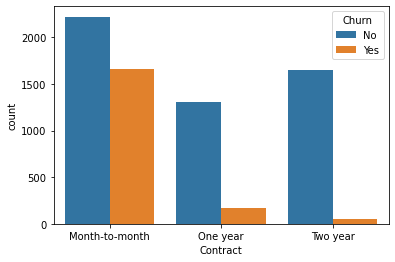

In [6]:
sns.countplot(x="Contract",hue="Churn",data=df)
# plt.title("Churn by Contract Type")
# plt.show()

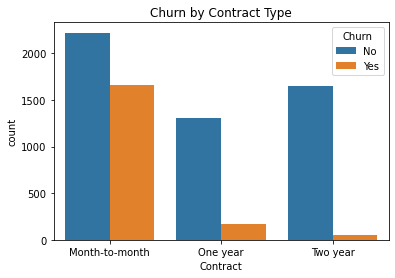

In [7]:
sns.countplot(x="Contract",hue="Churn",data=df)
plt.title("Churn by Contract Type")
plt.show()

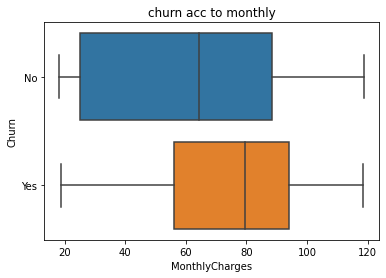

In [8]:
sns.boxplot(x="MonthlyCharges",y="Churn",data=df)
plt.title("churn acc to monthly")
plt.show()

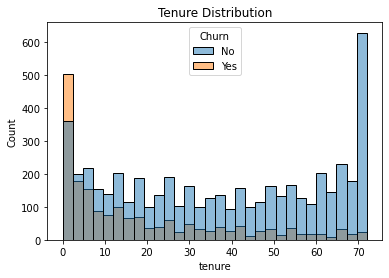

In [9]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,)
# ns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure Distribution")
plt.show()

<AxesSubplot:>

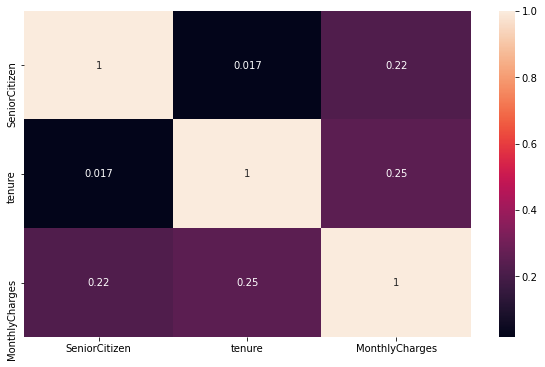

In [10]:
plt.figure(figsize=(10,6))

numer_df=df.select_dtypes(include=['int64','float64'])

sns.heatmap(numer_df.corr(),annot=True)

In [11]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
X = df.drop(["Churn", "customerID"], axis=1)
y=df['Churn'].map({'No': 0, 'Yes': 1})  

In [53]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [52]:
y.info

<bound method Series.info of 0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64>

##  Train-Test Split

- Split dataset into training and testing sets
- Maintain distribution using stratification

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
num_col=X.select_dtypes(include=['int64','float64']).columns
catcol=X.select_dtypes(include='object').columns

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report,accuracy_score

preprcoessor=ColumnTransformer(transformers=[('num',StandardScaler(),num_col),('cat',OneHotEncoder(handle_unknown="ignore"),catcol)])

# Model Training

We train multiple models:
- Logistic Regression
- Random Forest
- Gradient Boosting / XGBoost

Goal:
- Compare performance
- Select best model

In [18]:
log_pipeline=Pipeline(steps=[("preprocessing",preprcoessor),("model",LogisticRegression())])

log_pipeline.fit(X_train,y_train )

ypred=log_pipeline.predict(X_test)

print("Accuracy---->",accuracy_score(y_test,ypred))
print("---------------------------------------------------------------")
print("              Classification Report                              ")
print(classification_report(y_test,ypred))

Accuracy----> 0.8239886444286728
---------------------------------------------------------------
              Classification Report                              
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.70      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
random_pipeline=Pipeline(steps=[("processor",preprcoessor),("model",RandomForestClassifier())])

random_pipeline.fit(X_train,y_train)

ypred=random_pipeline.predict(X_test)

print("Accuracy---->",accuracy_score(y_test,ypred))
print("---------------------------------------------------------------")
print("              Classification Report                              ")
print(classification_report(y_test,ypred))

Accuracy----> 0.794889992902768
---------------------------------------------------------------
              Classification Report                              
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [21]:
from xgboost import XGBClassifier


In [25]:
xgb_pipeline=Pipeline(steps=[("processor",preprcoessor),("model",XGBClassifier(use_label_encoder=False, eval_metric='logloss'))])

xgb_pipeline.fit(X_train,y_train)

ypred=xgb_pipeline.predict(X_test)


print("Accuracy---->",accuracy_score(y_test,ypred))
print("---------------------------------------------------------------")
print("              Classification Report                              ")
print(classification_report(y_test,ypred))

Accuracy----> 0.7899219304471257
---------------------------------------------------------------
              Classification Report                              
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1036
           1       0.62      0.53      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



## Voting Classifier

In [23]:
from sklearn.ensemble import VotingClassifier

In [27]:
model = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression()),
        ("rf", RandomForestClassifier()),
        ("xgb", XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
    ],
    voting='soft'
)

final_pipeline = Pipeline([
    ("preprocessing", preprcoessor),
    ("model", model)
])

# Train
final_pipeline.fit(X_train, y_train)

# Predict
ypred = final_pipeline.predict(X_test)




print("Accuracy---->",accuracy_score(y_test,ypred))
print("---------------------------------------------------------------")
print("              Classification Report                              ")
print(classification_report(y_test,ypred))

Accuracy----> 0.8034066713981547
---------------------------------------------------------------
              Classification Report                              
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.51      0.58       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



## USING GRIDCV To FIND BEST PARAMS

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__rf__n_estimators": [100, 200],
    "model__rf__max_depth": [5, 10],
    "model__xgb__n_estimators": [100],
    "model__xgb__learning_rate": [0.01, 0.1],
    "model__lr__C": [0.1, 1]
}

grid = GridSearchCV(final_pipeline, param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup',...
                                                                                    min_child_weight=None,
                                                                                    missing=nan,
                                                                                    monotone_constraints=None,
                                                                                    multi_strategy=None,
                                                                                    n_estimators=None,
                                                                                    n_jobs=None,
                                                                                    num_parallel_tree=None,
                                                                                    random_state=None, ...))],
                                                         voting='soft'))]),
             param_grid={'model__lr__C': [0.1, 1],
                         'model__rf__max_depth': [5, 10],
                         'model__rf__n_estimators': [100, 200],
                         'model__xgb__learning_rate': [0.01, 0.1],
                         'model__xgb__n_estimators': [100]},
             scoring='accuracy')

In [29]:
print("Best Score:", grid.best_score_)
print("Best Params:", grid.best_params_)

Best Score: 0.8017391619556156
Best Params: {'model__lr__C': 1, 'model__rf__max_depth': 10, 'model__rf__n_estimators': 100, 'model__xgb__learning_rate': 0.1, 'model__xgb__n_estimators': 100}


In [30]:
y_pred = grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8105039034776437


In [67]:
best_model=grid.best_estimator_

In [68]:
y_pred=best_model.predict(X_test)
y_prob=best_model.predict_proba(X_test)[:,1]

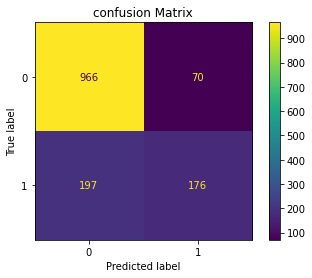

In [69]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("confusion Matrix")
plt.show()

No handles with labels found to put in legend.


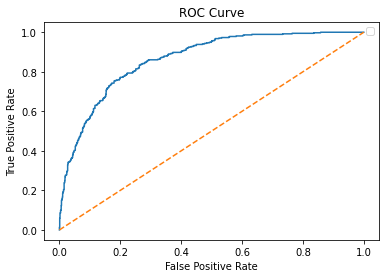

In [79]:
from sklearn.metrics import roc_curve,auc
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
roc_auc=auc(fpr,tpr)

plt.figure()
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## Model Saving

- Save model using pickle
- Enables deployment and reuse

In [31]:
import joblib

joblib.dump(grid.best_estimator_, "churn_model.pkl")

['churn_model.pkl']

In [64]:
joblib.dump(X_train.columns, "columns.pkl")
joblib.dump(preprcoessor, "label_encoder.pkl")

['label_encoder.pkl']

## Conclusion

- Built an end-to-end churn prediction system
- Identified key drivers of churn
- Improved recall for detecting churn customers

### Key Takeaways
- Handling imbalance is critical
- Pipelines improve workflow efficiency
- Recall is more important than accuracy in churn problems